In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show
from shapely.geometry import Polygon, Point
from rasterio.features import shapes
#from rtree import index

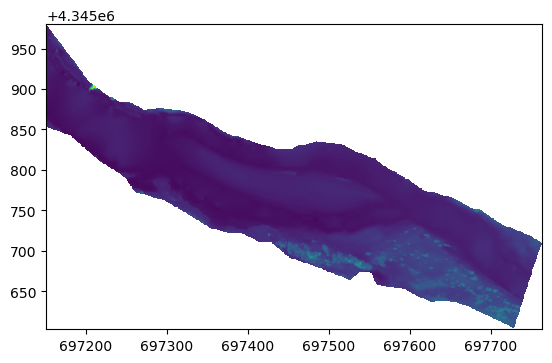

<AxesSubplot: >

In [2]:
#open the raster utm datasets
riverBat = rasterio.open('../l1processedData/Rst/riverBathymetry.tif')
surfElev = rasterio.open('../l1processedData/Rst/OHIO_2021_16N_m.tif')
show(riverBat)

In [3]:
#get no data value
rivNodata = riverBat.nodata
rivNodata

-9999.0

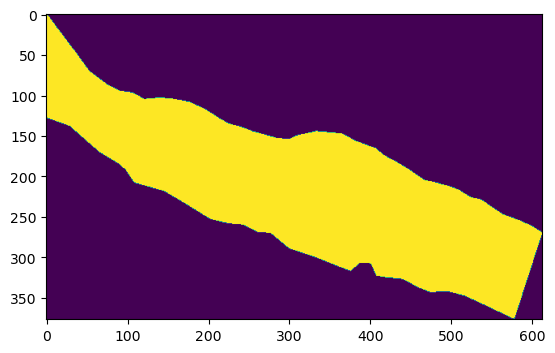

In [4]:
#create an array of the active river
bath = riverBat.read(1)
activeRiver = np.zeros(bath.shape)
activeRiver[bath > riverBat.nodata] = 1
plt.imshow(activeRiver)

In [5]:
#creating a contour over the active river
polys = shapes(activeRiver, connectivity=8, transform=riverBat.transform)

In [6]:
#looping over the polygon generator to create a geospatial polygon
hugePolys = []

for poly in polys:
    #print(poly)
    shpPol = Polygon(poly[0]['coordinates'][0])
    #print(shpPol.area)
    if shpPol.area > 40000 and poly[1]==1:
        #print(poly[0])
        print(shpPol.area)
        hugePolys.append(shpPol)

75702.0


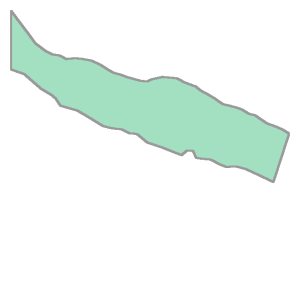

In [7]:
# show resulting polygon
hugePolys[0]

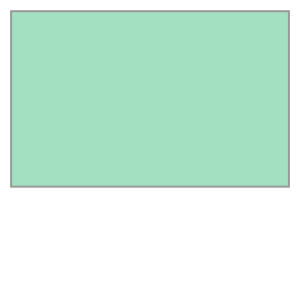

In [8]:
#open the aoi
aoi = gpd.read_file('../l1processedData/Shp/Model/aoiExtended.shp')
aoi.iloc[0].geometry

In [9]:
#explore the aoi bounds
bounds = aoi.total_bounds
bounds

array([ 697160., 4345610.,  697730., 4345970.])

In [10]:
xMin, xMax = bounds[0], bounds[2]
yMin, yMax = bounds[1], bounds[3]

In [11]:
res = 1 #output raster resolution of 1m

In [12]:
#define the cell centers arrays
xArray = np.arange(xMin,xMax,res)
yArray = np.arange(yMin,yMax,res)
yArray[:5]

array([4345610., 4345611., 4345612., 4345613., 4345614.])

In [13]:
#get nrows and ncols
nrow = yArray.shape[0]
ncol = xArray.shape[0]
print(nrow,ncol)

360 570


In [14]:
#get no data value
riverNodata = riverBat.nodata

#create sample array
topoBath = np.zeros([nrow,ncol])



In [15]:
i = 0

for row in range(nrow):
    for col in range(ncol):
        
        colX = xArray[col]
        rowY = yArray[row]

        # create a point object of the xy
        pixel = Point(colX,rowY)
        #apply value of bathymetry if available
        if hugePolys[0].contains(pixel):
            #extract raster values
            bathValue = list(riverBat.sample([(colX,rowY)]))[0]
            bathValue = bathValue.tolist()[0]
            #check if sampled values are empty
            if bathValue == riverNodata:
                topoBath[row,col] = topoBath[row,col-1]
            else:
                topoBath[row,col] = bathValue
        else:
            surfValue = list(surfElev.sample([(colX,rowY)]))[0]
            surfValue = surfValue.tolist()[0]
            topoBath[row,col] = surfValue

        #counter
        if i % 1000 ==0:
            print(f'\r %d'%i, end="", flush=True)

        i+=1    

 205000

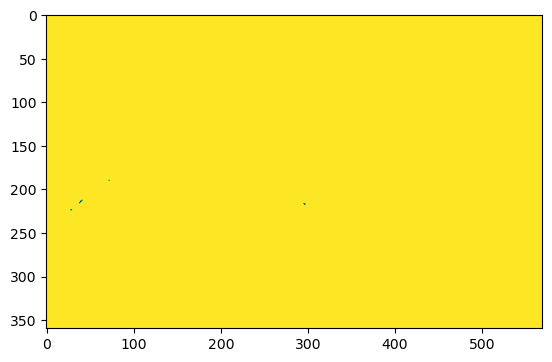

In [16]:
#preview of the topo array (inverted)
plt.imshow(topoBath)

In [17]:
#definition of the raster transform array
from rasterio.transform import Affine
#transform = Affine.translation(xArray[0]-res/2, yArray[0]-res/2)*Affine.scale(res,res)
top = yArray[-1] + res  # or just yMax, works either way
transform = Affine.translation(xMin, top) * Affine.scale(res, -res)
transform

Affine(1.0, 0.0, 697160.0,
       0.0, -1.0, 4345970.0)

In [18]:
# Flip the array so row 0 = north (max y), matching the transform above
topoBathOut = np.flipud(topoBath)

In [19]:
#get crs as wkt
from rasterio.crs import CRS
rasterCrs = CRS.from_epsg(32616)
rasterCrs.data

{'proj': 'utm', 'zone': 16, 'datum': 'WGS84', 'units': 'm', 'no_defs': True}

In [20]:
#definition, register and close of interpolated raster
interpRaster = rasterio.open('../l1processedData/Rst/topoBath_'+str(res)+'m.tif',
                                'w',
                                driver='GTiff',
                                height=nrow,
                                width=ncol,
                                count=1,
                                dtype=topoBath.dtype,
                                crs=rasterCrs,
                                transform=transform,
                                )
interpRaster.write(topoBathOut,1)
interpRaster.close()